In [1]:
import os
import numpy as np
import pandas as pd
import networkx as nx
import gseapy as gp
from gseapy.plot import gseaplot
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
path_parent = os.path.dirname(os.path.dirname(os.path.abspath('ks_association.ipynb')))
rank_mtx_f = open(path_parent + ('/deseq/res/rank_matrix_padj_cutoff_001.txt'),'r')
rank_mtx_raw = rank_mtx_f.readlines()
rank_mtx_f.close()

In [3]:
virus_names = rank_mtx_raw[0].strip().split('\t')
rank_dict = {}
for name in virus_names:
    rank_dict[name] = []

for line in rank_mtx_raw[1:]:
    line = line.strip().split('\t')
    for idx,name in enumerate(virus_names):
        rank_dict[name].append([line[0],int(line[idx+1])])

Generate gmt file using the top 250 genes

In [7]:
with open('top250.gmt', 'a') as file:
    for name in rank_dict.keys():
        df=pd.DataFrame(rank_dict[name], columns=['gene','rnk'])
        df.rnk = df.rnk.astype(int)
        df=df.sort_values(by="rnk")
        test='\t'.join(map(str,df.gene[0:250]))
        test=name+"\t"+test+"\n"
        file.write(test)
file.close()

with open('bottom250.gmt', 'a') as file:
    for name in rank_dict.keys():
        df=pd.DataFrame(rank_dict[name], columns=['gene','rnk'])
        df.rnk = df.rnk.astype(int)
        df=df.sort_values(by="rnk")
        test='\t'.join(map(str,df.gene[len(df.gene)-250:len(df.gene)]))
        test=name+"\t"+test+"\n"
        file.write(test)
file.close()

Compute Enrichment Score via GSEA prerank

In [8]:
es_top = pd.DataFrame() 

for name in rank_dict.keys():
    df=pd.DataFrame(rank_dict[name], columns=['gene','rnk'])
    df.rnk = df.rnk.astype(int)
    pre_res = gp.prerank(rnk=df, gene_sets='top250.gmt', ascending=True,
               outdir='gsea_out/prerank_report_top250/'+name, format='png', seed=6)  
    es_top[name]=pre_res.res2d.sort_index().es


In [9]:
es_bottom = pd.DataFrame() 

for name in rank_dict.keys():
    df=pd.DataFrame(rank_dict[name], columns=['gene','rnk'])
    df.rnk = df.rnk.astype(int)
    pre_res = gp.prerank(rnk=df, gene_sets='bottom250.gmt', ascending=True,
               outdir='gsea_out/prerank_report_bottom250/'+name, format='png', seed=6)  
    es_bottom[name]=pre_res.res2d.sort_index().es


In [10]:
es_top = es_top.reindex(sorted(es_top.columns), axis=1)
es_bottom = es_bottom.reindex(sorted(es_bottom.columns), axis=1)

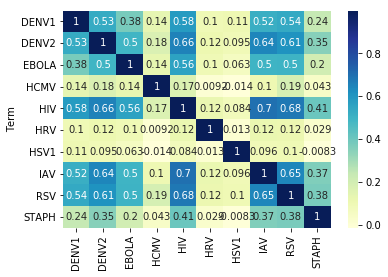

In [15]:
es=es_top.copy()

for i in range(len(virus_names)):
    for j in range(len(virus_names)):
        es.iloc[i][j]=(es_top.iloc[i][j]+es_top.iloc[j][i]-es_bottom.iloc[i][j]-es_bottom.iloc[j][i])/4.0

sns.heatmap(es, annot=True,   cmap="YlGnBu")


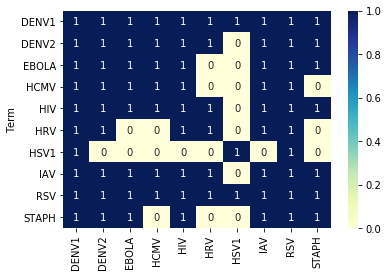

In [12]:
AS_cutoff=0.1
es_binary=es.copy()

for i in range(len(virus_names)):
    for j in range(len(virus_names)):
        if(es.iloc[i][j]>=AS_cutoff):
            es_binary.iloc[i][j]=1
        else:
            es_binary.iloc[i][j]=0

sns.heatmap(es_binary, annot=True,   cmap="YlGnBu")

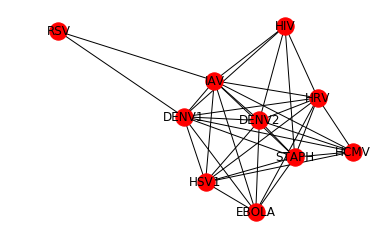

In [13]:
adj_mtrx_unweighted=es_binary.to_numpy()
G = nx.Graph(adj_mtrx_unweighted)
nameMap={}
for i in list(G.nodes()):
    nameMap[i]=virus_names[i]
G=nx.relabel_nodes(G,nameMap)
pos=nx.spring_layout(G)
labels = nx.draw_networkx_labels(G, pos)
nx.draw(G, pos)
plt.show()
